# Proyek Analisis Data: Bike-sharing-dataset
- **Nama:** Thoriq Kemal
- **Email:** thoriqekemal@gmail.com
- **ID Dicoding:** thoriqkemal

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1 : Berapa total terpinjam pada bulan November 2012?
- Pertanyaan 2 : Sepeda paling ramai dan sepi dipinjam pada musim apa?
- Pertanyaan 3 : Bagaimana kinerja peminjaman dalam setahun terakhir?

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

### Dataset Info

Data Set Information:
Bike sharing systems are new generation of traditional bike rentals where whole process from membership, rental and return back has become automatic. Through these systems, user is able to easily rent a bike from a particular position and return back at another position. Currently, there are about over 500 bike-sharing programs around the world which is composed of over 500 thousands bicycles. Today, there exists great interest in these systems due to their important role in traffic, environmental and health issues.
Apart from interesting real world applications of bike sharing systems, the characteristics of data being generated by these systems make them attractive for the research. Opposed to other transport services such as bus or subway, the duration of travel, departure and arrival position is explicitly recorded in these systems. This feature turns bike sharing system into a virtual sensor network that can be used for sensing mobility in the city. Hence, it is expected that most of important events in the city could be detected via monitoring these data.

Attribute Information:
Both hour.csv and day.csv have the following fields, except hr which is not available in day.csv

    instant: record index
    dteday : date
    season : season (1:springer, 2:summer, 3:fall, 4:winter)
    yr : year (0: 2011, 1:2012)
    mnth : month ( 1 to 12)
    hr : hour (0 to 23)
    holiday : weather day is holiday or not (extracted from [Web Link])
    weekday : day of the week
    workingday : if day is neither weekend nor holiday is 1, otherwise is 0.
    weathersit :
    1: Clear, Few clouds, Partly cloudy, Partly cloudy
    2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
    3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
    4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog
    temp : Normalized temperature in Celsius. The values are derived via (t-t_min)/(t_max-t_min), t_min=-8, t_max=+39 (only in hourly scale)
    atemp: Normalized feeling temperature in Celsius. The values are derived via (t-t_min)/(t_max-t_min), t_min=-16, t_max=+50 (only in hourly scale)
    hum: Normalized humidity. The values are divided to 100 (max)
    windspeed: Normalized wind speed. The values are divided to 67 (max)
    casual: count of casual users
    registered: count of registered users
    cnt: count of total rental bikes including both casual and registered

## Data Wrangling

### Gathering Data

In [2]:
day_df = pd.read_csv("data/day.csv")
day_df.sample(5)

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
636,637,2012-09-28,4,1,9,0,5,1,2,0.619167,0.585863,0.690000,0.164179,1045,6370,7415
685,686,2012-11-16,4,1,11,0,5,1,1,0.345000,0.347204,0.524583,0.171025,484,5214,5698
32,33,2011-02-02,1,0,2,0,3,1,2,0.260000,0.254417,0.775417,0.264308,72,1454,1526
404,405,2012-02-09,1,1,2,0,4,1,1,0.265000,0.261988,0.562083,0.194037,163,3667,3830
680,681,2012-11-11,4,1,11,0,0,0,1,0.420833,0.421713,0.659167,0.127500,2290,4562,6852


In [3]:
hour_df = pd.read_csv("data/hour.csv")
hour_df.sample(5)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
12407,12408,2012-06-06,2,1,6,4,0,3,1,1,0.46,0.4545,0.82,0.1045,3,7,10
2700,2701,2011-04-27,2,0,4,10,0,3,1,2,0.62,0.5758,0.83,0.2836,26,66,92
13233,13234,2012-07-10,3,1,7,14,0,2,1,1,0.82,0.7273,0.38,0.1642,71,171,242
1308,1309,2011-02-27,1,0,2,17,0,0,0,1,0.42,0.4242,0.54,0.1940,66,121,187
1773,1774,2011-03-19,1,0,3,14,0,6,0,1,0.50,0.4848,0.31,0.4925,168,144,312


In [4]:
total_transactions = hour_df.groupby('dteday')['cnt'].sum().reset_index()
print("Total Transactions per Day:", total_transactions)

Total Transactions per Day:          dteday   cnt
0    2011-01-01   985
1    2011-01-02   801
2    2011-01-03  1349
3    2011-01-04  1562
4    2011-01-05  1600
..          ...   ...
726  2012-12-27  2114
727  2012-12-28  3095
728  2012-12-29  1341
729  2012-12-30  1796
730  2012-12-31  2729

[731 rows x 2 columns]


### Assessing Data

In [5]:
print(hour_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB
None


In [6]:
print("Total records:", hour_df.count())

Total records: instant       17379
dteday        17379
season        17379
yr            17379
mnth          17379
hr            17379
holiday       17379
weekday       17379
workingday    17379
weathersit    17379
temp          17379
atemp         17379
hum           17379
windspeed     17379
casual        17379
registered    17379
cnt           17379
dtype: int64


In [7]:
print("Total Unique Values:", hour_df.nunique())

Total Unique Values: instant       17379
dteday          731
season            4
yr                2
mnth             12
hr               24
holiday           2
weekday           7
workingday        2
weathersit        4
temp             50
atemp            65
hum              89
windspeed        30
casual          322
registered      776
cnt             869
dtype: int64


In [8]:
print("Total Missing Values:", hour_df.isna().sum())

Total Missing Values: instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


Tidak ada data yang hilang

In [9]:
print("Total Duplicate Records:", hour_df.duplicated().sum())

Total Duplicate Records: 0


Tidak ada data yang duplikat

In [10]:
print("Summary statistics:")
print(hour_df.describe())

Summary statistics:
          instant        season            yr          mnth            hr  \
count  17379.0000  17379.000000  17379.000000  17379.000000  17379.000000   
mean    8690.0000      2.501640      0.502561      6.537775     11.546752   
std     5017.0295      1.106918      0.500008      3.438776      6.914405   
min        1.0000      1.000000      0.000000      1.000000      0.000000   
25%     4345.5000      2.000000      0.000000      4.000000      6.000000   
50%     8690.0000      3.000000      1.000000      7.000000     12.000000   
75%    13034.5000      3.000000      1.000000     10.000000     18.000000   
max    17379.0000      4.000000      1.000000     12.000000     23.000000   

            holiday       weekday    workingday    weathersit          temp  \
count  17379.000000  17379.000000  17379.000000  17379.000000  17379.000000   
mean       0.028770      3.003683      0.682721      1.425283      0.496987   
std        0.167165      2.005771      0.465431  

### Cleaning Data

**outliers**

In [11]:
q1 = hour_df['cnt'].quantile(0.25)
q3 = hour_df['cnt'].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)

is_outlier = (hour_df['cnt'] < lower_bound) | (hour_df['cnt'] > upper_bound)

total_outliers = is_outlier.sum()
print(f"Total outlier : {total_outliers}")

Total outlier : 505


karena jumlah outlier hanya sedikit jadi bisa langsung didrop

In [12]:
hour_df = hour_df[(hour_df['cnt'] >= lower_bound) & (hour_df['cnt'] <= upper_bound)]
hour_df.sample(5)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
12131,12132,2012-05-25,2,1,5,16,0,5,1,1,0.78,0.7121,0.52,0.2239,137,447,584
10971,10972,2012-04-07,2,1,4,7,0,6,0,1,0.32,0.3030,0.33,0.2836,14,40,54
17021,17022,2012-12-17,4,1,12,0,0,1,1,2,0.38,0.3939,0.87,0.0000,2,26,28
7238,7239,2011-11-03,4,0,11,5,0,4,1,1,0.32,0.3333,0.81,0.1343,1,27,28
4660,4661,2011-07-18,3,0,7,2,0,1,1,1,0.66,0.6061,0.83,0.2239,2,8,10


**Memperbaiki tipe data**

In [13]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16874 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     16874 non-null  int64  
 1   dteday      16874 non-null  object 
 2   season      16874 non-null  int64  
 3   yr          16874 non-null  int64  
 4   mnth        16874 non-null  int64  
 5   hr          16874 non-null  int64  
 6   holiday     16874 non-null  int64  
 7   weekday     16874 non-null  int64  
 8   workingday  16874 non-null  int64  
 9   weathersit  16874 non-null  int64  
 10  temp        16874 non-null  float64
 11  atemp       16874 non-null  float64
 12  hum         16874 non-null  float64
 13  windspeed   16874 non-null  float64
 14  casual      16874 non-null  int64  
 15  registered  16874 non-null  int64  
 16  cnt         16874 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


#### Change datatype `date` to `datetime` object

In [14]:
for df in [day_df, hour_df]:
    df['dteday'] = pd.to_datetime(df['dteday'])

#### Change column name for readability

In [15]:
for df in [day_df, hour_df]:
    df.rename(columns={
        'yr': 'year',
        'mnth': 'month',
        'hr': 'hour',
        'weathersit': 'weather_condition',
        'hum': 'humidity',
        'cnt': 'total_count'
    }, inplace=True)

In [28]:
print('After data processing:', hour_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 16874 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   instant            16874 non-null  int64         
 1   dteday             16874 non-null  datetime64[ns]
 2   season             16874 non-null  int64         
 3   year               16874 non-null  int64         
 4   month              16874 non-null  int64         
 5   hour               16874 non-null  int64         
 6   holiday            16874 non-null  int64         
 7   weekday            16874 non-null  int64         
 8   workingday         16874 non-null  int64         
 9   weather_condition  16874 non-null  int64         
 10  temp               16874 non-null  float64       
 11  atemp              16874 non-null  float64       
 12  humidity           16874 non-null  float64       
 13  windspeed          16874 non-null  float64       
 14  casual     

## Exploratory Data Analysis (EDA)

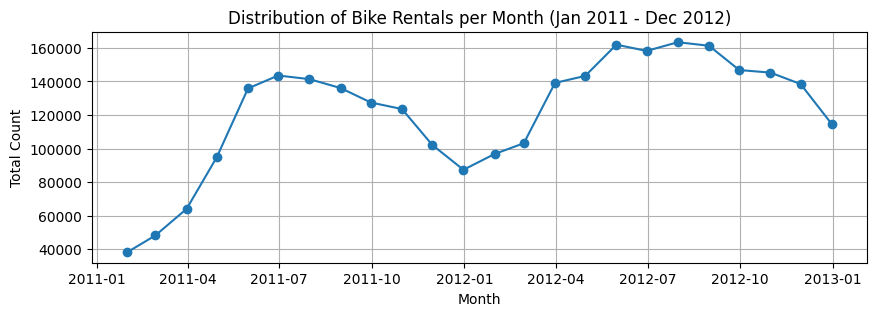

In [17]:
monthly = hour_df.groupby(pd.Grouper(key='dteday', freq='ME')).sum()
plt.figure(figsize=(10, 3))
plt.plot(monthly.index, monthly['total_count'],marker='o',linestyle='-')
plt.title('Distribution of Bike Rentals per Month (Jan 2011 - Dec 2012)')
plt.xlabel('Month')
plt.ylabel('Total Count')
plt.grid(True)
plt.show()

In [18]:
features = ['month', 'hour', 'weekday', 'temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered']
for feature in features:
    fig = px.histogram(hour_df, x=feature, y='total_count', title=f'Distribution of {feature.capitalize()}')
    fig.update_traces(marker_line_color='black', marker_line_width=1)
    fig.update_layout(yaxis_title='Total Count', xaxis_title=feature.capitalize())
    fig.show()

In [19]:
features = ['season', 'year', 'holiday', 'workingday', 'weather_condition']

for feature in features:
    proper_label = feature.replace('_', ' ').capitalize()
    
    fig = px.pie(hour_df, 
                 names=feature, 
                 values='total_count',
                 title=f'Distribution based on {proper_label}') 
    fig.show()

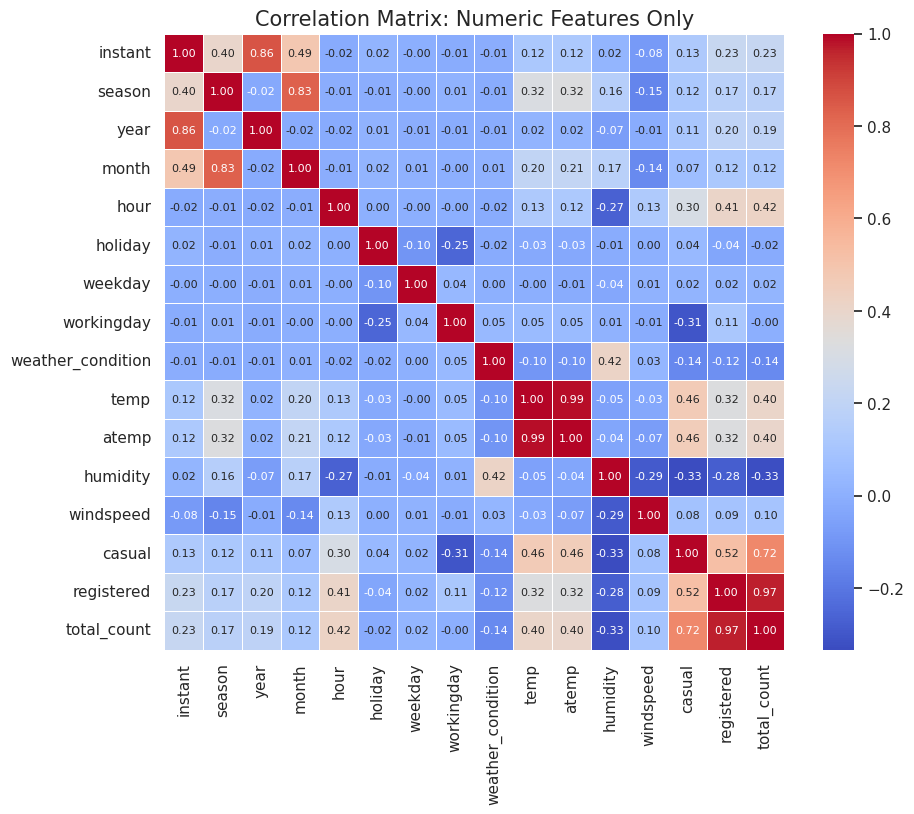

In [20]:
correlation = hour_df.corr(numeric_only=True)

sns.set_theme(style="white")
plt.figure(figsize=(10, 8))

sns.heatmap(correlation, 
            annot=True, 
            fmt=".2f",
            cmap='coolwarm', 
            linewidths=0.5, 
            annot_kws={"size": 8})

plt.title('Correlation Matrix: Numeric Features Only', fontsize=15)
plt.show()


## Visualization & Explanatory Analysis

### Pertanyaan 1: Berapa total terpinjam pada bulan November 2012?

In [21]:
total = hour_df[(hour_df['year'] == 1) & (hour_df['month'] == 12)]['total_count'].sum()

print("Total count in December 2012:", total)

Total count in December 2012: 114538


### Pertanyaan 2: Sepeda paling ramai dan sepi dipinjam pada musim apa?

In [27]:
count_per_season = hour_df.groupby('season')['total_count'].sum().reset_index()

peak_season = count_per_season.loc[count_per_season['total_count'].idxmax()]
low_season = count_per_season.loc[count_per_season['total_count'].idxmin()]

print("Peak season:", peak_season['season'])
print("Low season:", low_season['season'])

Peak season: 3
Low season: 1


### Pertanyaan 3: Bagaimana kinerja peminjaman dalam setahun terakhir?

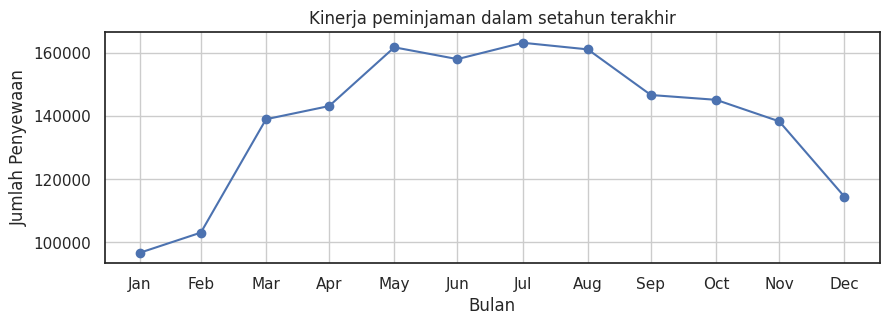

In [23]:
data = hour_df[hour_df['year'] == 1]
bulan = data.groupby(pd.Grouper(key='dteday', freq='ME')).sum()
plt.figure(figsize=(10, 3))
plt.plot(bulan.index, bulan['total_count'], marker='o', linestyle='-')
plt.xticks(bulan.index, bulan.index.strftime('%b'))
plt.title('Kinerja peminjaman dalam setahun terakhir')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Penyewaan')
plt.grid(True)
plt.show()

In [24]:
# Grouping by year to compare 2011 (0) and 2012 (1)
yoy_performance = hour_df.groupby('year')['total_count'].sum().reset_index()
yoy_performance['year'] = yoy_performance['year'].map({0: 2011, 1: 2012})
print(yoy_performance)

   year  total_count
0  2011      1242452
1  2012      1671859


In [25]:
# Create a pivot table for months and years
monthly_yoy = day_df.groupby(['month', 'year'])['total_count'].sum().unstack()
monthly_yoy.columns = ['2011', '2012']

# Calculate percentage growth
monthly_yoy['YoY_Growth_Pct'] = ((monthly_yoy['2012'] - monthly_yoy['2011']) / monthly_yoy['2011']) * 100
print(monthly_yoy)

         2011    2012  YoY_Growth_Pct
month                                
1       38189   96744      153.329493
2       48215  103137      113.910609
3       64045  164875      157.436178
4       94870  174224       83.644988
5      135821  195865       44.208186
6      143512  202830       41.333129
7      141341  203607       44.053742
8      136691  214503       56.925474
9      127418  218573       71.540128
10     123511  198841       60.990519
11     102167  152664       49.425940
12      87323  123713       41.672870


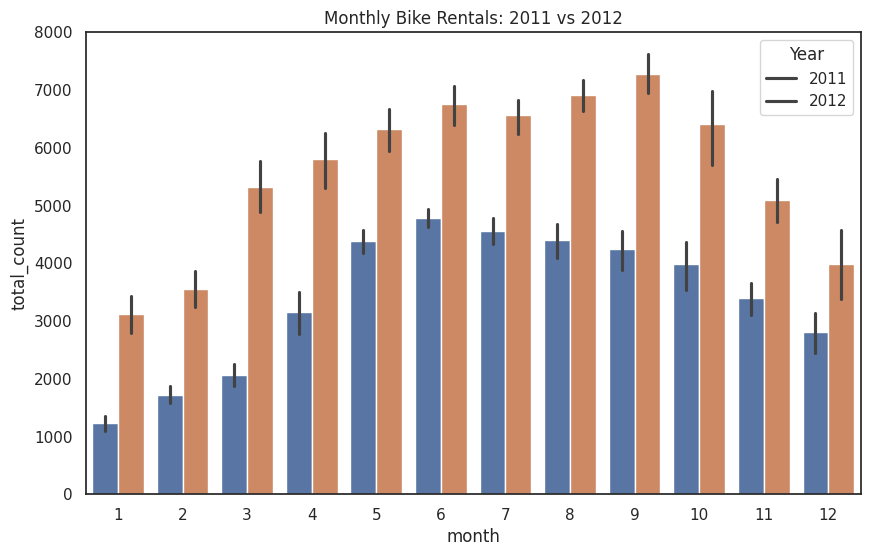

In [26]:
plt.figure(figsize=(10,6))
sns.barplot(data=day_df, x='month', y='total_count', hue='year')
plt.title('Monthly Bike Rentals: 2011 vs 2012')
plt.legend(title='Year', labels=['2011', '2012'])
plt.show()

## Conclusion

- Conclution pertanyaan 1: Total sepeda terpinjam pada bulan November 2012 yaitu 138.423
- Conclution pertanyaan 2: Orang-orang paling banyak meminjam sepeda pada musim panas sedangkan paling sedikit pada musim dingin
- Conclution pertanyaan 3: dari bulan januari hingga mei peminjaman sepeda terus meningkat, sempat turun sedikit pada bulan juni, dan naik kembali pada bulan juli (bulan dengan jumlah peminjaman terbanyak selama tahun 2012),namun setelah bulan juli jumlah peminjaman sepeda terus berkurang
- Berdasarkan matriks korelasi didapatkan faktor yang paling berpengaruh yaitu jam peminjaman. Dan berdasarkan distribusinya, sepeda paling sering dipinjam pada pukul 4 sore hingga 7 malam
- Selain jam, suhu juga sangat berpengaruh pada minat meminjam. Suhu yang dirasa nyaman untuk bersepeda yakni pada suhu 0.6 hingga 0.7 Celsius